# Non-Profit Donation Prediction

### Preparations

In [1]:
# !python chapter_setup.py

In [4]:
# Install the missing library
!apt-get update && apt-get install -y libgl1-mesa-glx

Get:1 http://security.ubuntu.com/ubuntu focal-security InRelease [128 kB]
Hit:2 http://archive.ubuntu.com/ubuntu focal InRelease
Get:3 http://archive.ubuntu.com/ubuntu focal-updates InRelease [128 kB]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2004/x86_64  InRelease [1581 B]
Get:5 http://archive.ubuntu.com/ubuntu focal-backports InRelease [128 kB]
Get:6 http://ppa.launchpad.net/deadsnakes/ppa/ubuntu focal InRelease [18.1 kB]
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2004/x86_64  Packages [2686 kB]
Get:8 http://security.ubuntu.com/ubuntu focal-security/multiverse amd64 Packages [33.1 kB]
Get:9 http://security.ubuntu.com/ubuntu focal-security/universe amd64 Packages [1308 kB]
Get:10 http://security.ubuntu.com/ubuntu focal-security/restricted amd64 Packages [4801 kB]
Get:11 http://security.ubuntu.com/ubuntu focal-security/main amd64 Packages [4431 kB]
Get:12 http://archive.ubuntu.com/ubuntu focal-updates/restricted amd64 Packages [4998 

### Loading Libraries

In [58]:
# Numerical Computing
import math
import numpy as np

# Data Manipulation
import pandas as pd

# Data Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# OS
import os

# Dataset Source
import machine_learning_datasets as mldatasets

# Understanding The Effect of Irrelevant Features
import timeit
from tqdm.notebook import tqdm

# Filter-Based Methods
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, SelectKBest

# Embedded Methods
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression, LassoCV, LassoLarsCV, LassoLarsIC

# Wrapper Methods
from mlxtend.feature_selection import SequentialFeatureSelector

# Hybrid Methods
from sklearn.feature_selection import RFECV

# Advanced Methods
from sklearn.decomposition import PCA
import shap

from scipy.stats import rankdata

# Models
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [67]:
# from sklearn_genetic import GAFeatureSelectionCV

### Understanding & Preparing Data

In [70]:
X_train, X_test, y_train, y_test = mldatasets.load("nonprofit-mailer", prepare=True)

y_train = y_train.squeeze()
y_test = y_test.squeeze()

https://github.com/PacktPublishing/Interpretable-Machine-Learning-with-Python/raw/master/datasets/mailing-list.zip downloaded to /datasets/_deepnote_work/data/mailing-list.zip
/datasets/_deepnote_work/data/mailing-list.zip uncompressed to /datasets/_deepnote_work/data/mailing-list
2 dataset files found in /datasets/_deepnote_work/data/mailing-list folder
parsing /datasets/_deepnote_work/data/mailing-list/train.csv
parsing /datasets/_deepnote_work/data/mailing-list/test.csv


In [73]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(95485, 435)
(95485,)
(96017, 435)
(96017,)


In [76]:
var_cost = 0.68

y_test_donators = y_test[y_test > 0]
test_donators = len(y_test_donators)
test_donations = sum(y_test_donators)
test_min_profit = test_donations - (len(y_test)*var_cost)
test_max_profit = test_donations - (test_donators*var_cost)
print('%s test donators totaling $%.0f (min profit: $%.0f, max profit: $%.0f)' %\
      (test_donators, test_donations, test_min_profit, test_max_profit))

4894 test donators totaling $76464 (min profit: $11173, max profit: $73136)


In [79]:
y_train_donators = y_train[y_train > 0]

train_donators = len(y_train_donators)
train_donations = sum(y_train_donators)
train_min_profit = train_donations - (len(y_train)*var_cost)
train_max_profit = train_donations - (train_donators*var_cost)
print('%s train donators totaling $%.0f (min profit: $%.0f, max profit: $%.0f)' %\
      (train_donators, train_donations, train_min_profit, train_max_profit))

4812 train donators totaling $75113 (min profit: $10183, max profit: $71841)


## Understanding The Effect of Irrelevant Features

### Creating a Base Model

In [82]:
rand = 9
os.environ['PYTHONHASHSEED']=str(rand)
np.random.seed(rand)
orig_plt_params = plt.rcParams
sns.set()

In [85]:
%%time
stime = timeit.default_timer()
reg_mdl = xgb.XGBRFRegressor(max_depth=4, n_estimators=200, seed=rand)
fitted_mdl = reg_mdl.fit(X_train, y_train)
etime = timeit.default_timer()
baseline_time = etime-stime

CPU times: user 16.4 s, sys: 438 ms, total: 16.8 s
Wall time: 2.69 s


### Evaluating the Model

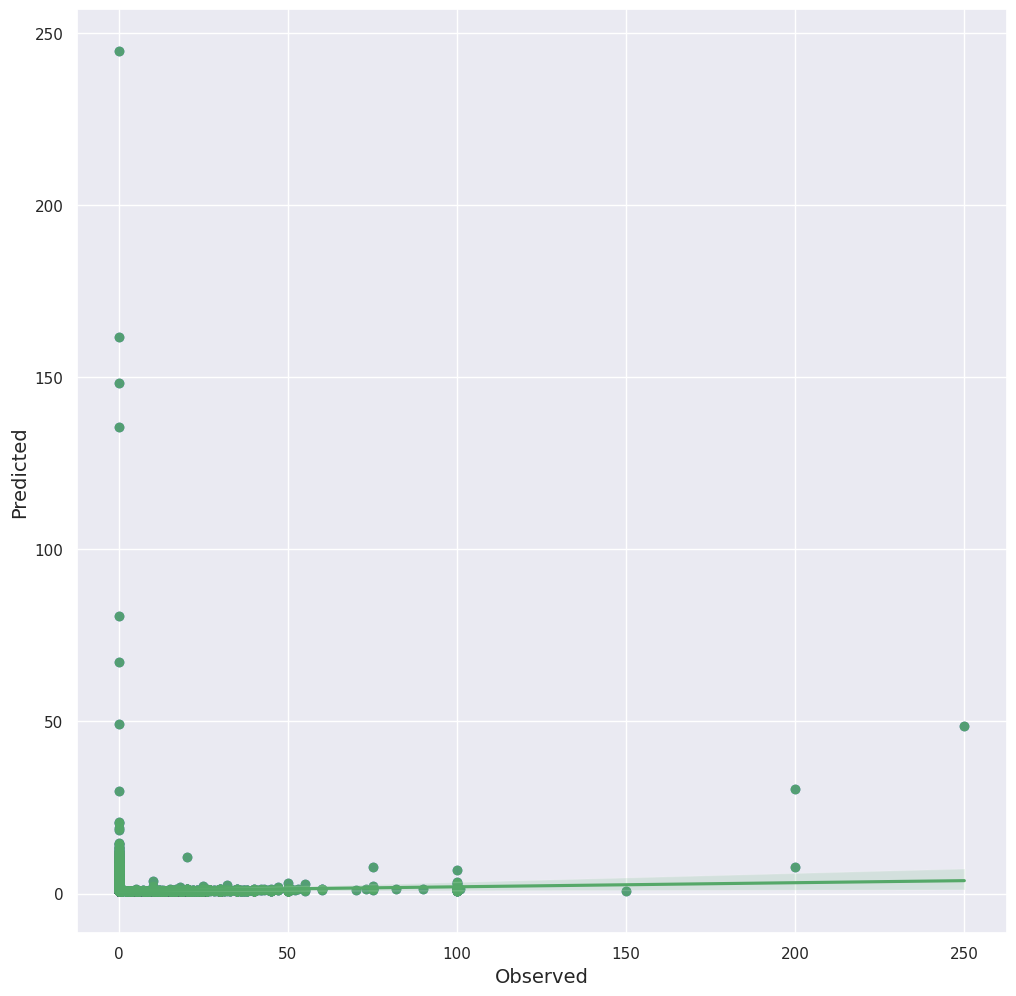

TypeError: got an unexpected keyword argument 'squared'

In [97]:
reg_mdls = {}
reg_mdls['rf_4_all'] = mldatasets.evaluate_reg_mdl(fitted_mdl, X_train, X_test, y_train, y_test,\
                                        plot_regplot=True, ret_eval_dict=True)
reg_mdls['rf_4_all']['speed'] = 1
reg_mdls['rf_4_all']['depth'] = 4
reg_mdls['rf_4_all']['fs'] = 'all'

In [100]:
threshs = np.hstack([np.linspace(0.40,1,61), np.linspace(1.1,3,20),\
                     np.linspace(4,25,22)])

In [106]:
# y_formatter = plt.FuncFormatter(lambda x, loc: "${:,}K".format(x/1000))

# profits_test = mldatasets.profits_by_thresh(y_test, reg_mdls['rf_4_all']['preds_test'],\
#                                     threshs, var_costs=var_cost, min_profit=test_min_profit)
# profits_train = mldatasets.profits_by_thresh(y_train, reg_mdls['rf_4_all']['preds_train'],\
#                                      threshs, var_costs=var_cost, min_profit=train_min_profit)
# reg_mdls['rf_4_all']['max_profit_train'] = profits_train.profit.max()
# reg_mdls['rf_4_all']['max_profit_test'] = profits_test.profit.max()
# reg_mdls['rf_4_all']['max_roi'] = profits_test.roi.max()
# reg_mdls['rf_4_all']['min_costs'] = profits_test.costs.min()
# reg_mdls['rf_4_all']['profits_train'] = profits_train
# reg_mdls['rf_4_all']['profits_test'] = profits_test

# mldatasets.compare_df_plots(profits_test[['costs', 'profit', 'roi']],\
#                             profits_train[['costs', 'profit', 'roi']],\
#                             'Test', 'Train', x_label='Threshold',\
#                             y_formatter=y_formatter, plot_args={'secondary_y':'roi'})

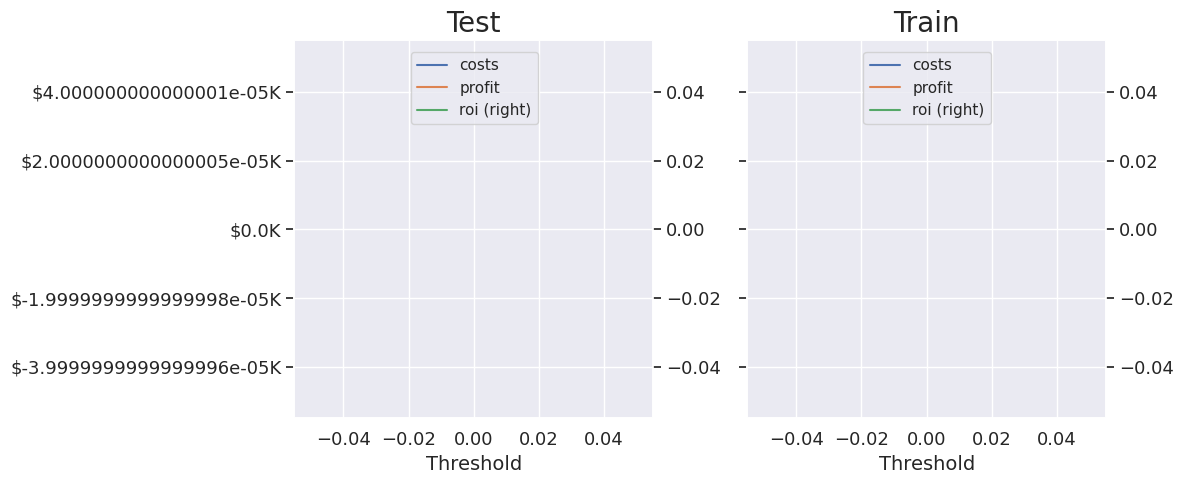

In [109]:
# Initialize the 'rf_4_all' key in the 'reg_mdls' dictionary
reg_mdls['rf_4_all'] = {}

# Now, re-run the code to populate the dictionary and avoid the KeyError
y_formatter = plt.FuncFormatter(lambda x, loc: "${:,}K".format(x/1000))

profits_test = mldatasets.profits_by_thresh(y_test, reg_mdls['rf_4_all'].get('preds_test', []),\
                                    threshs, var_costs=var_cost, min_profit=test_min_profit)
profits_train = mldatasets.profits_by_thresh(y_train, reg_mdls['rf_4_all'].get('preds_train', []),\
                                     threshs, var_costs=var_cost, min_profit=train_min_profit)
reg_mdls['rf_4_all']['max_profit_train'] = profits_train.profit.max()
reg_mdls['rf_4_all']['max_profit_test'] = profits_test.profit.max()
reg_mdls['rf_4_all']['max_roi'] = profits_test.roi.max()
reg_mdls['rf_4_all']['min_costs'] = profits_test.costs.min()
reg_mdls['rf_4_all']['profits_train'] = profits_train
reg_mdls['rf_4_all']['profits_test'] = profits_test

mldatasets.compare_df_plots(profits_test[['costs', 'profit', 'roi']],\
                            profits_train[['costs', 'profit', 'roi']],\
                            'Test', 'Train', x_label='Threshold',\
                            y_formatter=y_formatter, plot_args={'secondary_y':'roi'})

In [115]:
# Train the model again and store it in the dictionary
reg_mdl = xgb.XGBRFRegressor(max_depth=4, n_estimators=200, seed=rand)
fitted_mdl = reg_mdl.fit(X_train, y_train)

# Store the fitted model in the dictionary
reg_mdls['rf_4_all']['fitted'] = fitted_mdl

# Now, calculate the total and number of features
reg_mdls['rf_4_all']['total_feat'] = reg_mdls['rf_4_all']['fitted'].feature_importances_.shape[0]
reg_mdls['rf_4_all']['num_feat'] = sum(reg_mdls['rf_4_all']['fitted'].feature_importances_ > 0)
print(reg_mdls['rf_4_all']['num_feat'])

169


### Training Base Model at Different Max Depths

In [127]:
# %%time
# for depth in tqdm(range(5, 13)):
#     mdlname = 'rf_'+str(depth)+'_all'
#     stime = timeit.default_timer()
#     reg_mdl = xgb.XGBRFRegressor(max_depth=depth, n_estimators=200, seed=rand)
#     fitted_mdl = reg_mdl.fit(X_train, y_train)
#     etime = timeit.default_timer()
#     reg_mdls[mdlname] = mldatasets.evaluate_reg_mdl(fitted_mdl, X_train, X_test, y_train, y_test,\
#                                             plot_regplot=False, show_summary=False, ret_eval_dict=True)
#     reg_mdls[mdlname]['speed'] = (etime-stime)/baseline_time
#     reg_mdls[mdlname]['depth'] = depth
#     reg_mdls[mdlname]['fs'] = 'all'
#     profits_test = mldatasets.profits_by_thresh(y_test, reg_mdls[mdlname]['preds_test'],\
#                                     threshs, var_costs=var_cost, min_profit=test_min_profit)
#     profits_train = mldatasets.profits_by_thresh(y_train, reg_mdls[mdlname]['preds_train'],\
#                                     threshs, var_costs=var_cost, min_profit=train_min_profit)
#     reg_mdls[mdlname]['max_profit_train'] = profits_train.profit.max()
#     reg_mdls[mdlname]['max_profit_test'] = profits_test.profit.max()
#     reg_mdls[mdlname]['max_roi'] = profits_test.roi.max()
#     reg_mdls[mdlname]['min_costs'] = profits_test.costs.min()
#     reg_mdls[mdlname]['profits_train'] = profits_train
#     reg_mdls[mdlname]['profits_test'] = profits_test
#     reg_mdls[mdlname]['total_feat'] = reg_mdls[mdlname]['fitted'].feature_importances_.shape[0]
#     reg_mdls[mdlname]['num_feat'] = sum(reg_mdls[mdlname]['fitted'].feature_importances_ > 0)

In [130]:
from tqdm import tqdm

In [133]:
%%time
for depth in tqdm(range(5, 13)):
    mdlname = 'rf_'+str(depth)+'_all'
    stime = timeit.default_timer()
    reg_mdl = xgb.XGBRFRegressor(max_depth=depth, n_estimators=200, seed=rand)
    fitted_mdl = reg_mdl.fit(X_train, y_train)
    etime = timeit.default_timer()
    reg_mdls[mdlname] = mldatasets.evaluate_reg_mdl(fitted_mdl, X_train, X_test, y_train, y_test,\
                                            plot_regplot=False, show_summary=False, ret_eval_dict=True)
    reg_mdls[mdlname]['speed'] = (etime-stime)/baseline_time
    reg_mdls[mdlname]['depth'] = depth
    reg_mdls[mdlname]['fs'] = 'all'
    profits_test = mldatasets.profits_by_thresh(y_test, reg_mdls[mdlname]['preds_test'],\
                                    threshs, var_costs=var_cost, min_profit=test_min_profit)
    profits_train = mldatasets.profits_by_thresh(y_train, reg_mdls[mdlname]['preds_train'],\
                                    threshs, var_costs=var_cost, min_profit=train_min_profit)
    reg_mdls[mdlname]['max_profit_train'] = profits_train.profit.max()
    reg_mdls[mdlname]['max_profit_test'] = profits_test.profit.max()
    reg_mdls[mdlname]['max_roi'] = profits_test.roi.max()
    reg_mdls[mdlname]['min_costs'] = profits_test.costs.min()
    reg_mdls[mdlname]['profits_train'] = profits_train
    reg_mdls[mdlname]['profits_test'] = profits_test
    reg_mdls[mdlname]['total_feat'] = reg_mdls[mdlname]['fitted'].feature_importances_.shape[0]
    reg_mdls[mdlname]['num_feat'] = sum(reg_mdls[mdlname]['fitted'].feature_importances_ > 0)



  0%|          | 0/8 [00:02<?, ?it/s]
Exception ignored in: <function tqdm.__del__ at 0x7faefc86b130>
Traceback (most recent call last):
  File "/root/venv/lib/python3.10/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/root/venv/lib/python3.10/site-packages/tqdm/notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


TypeError: got an unexpected keyword argument 'squared'

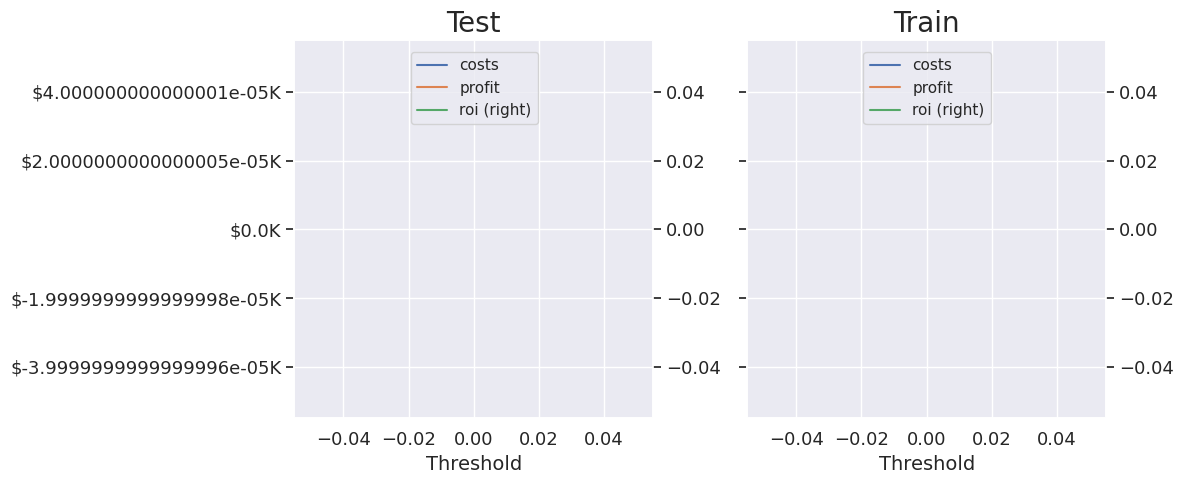

In [136]:
mldatasets.compare_df_plots(profits_test[['costs', 'profit', 'roi']],\
                            profits_train[['costs', 'profit', 'roi']],\
                            'Test', 'Train', x_label='Threshold',\
                            y_formatter=y_formatter, plot_args={'secondary_y':'roi'})

In [139]:
def display_mdl_metrics(reg_mdls, sort_by='depth', max_depth=None):
    reg_metrics_df = pd.DataFrame.from_dict(reg_mdls, 'index')\
                        [['depth', 'fs', 'rmse_train', 'rmse_test', 'max_profit_train',\
                          'max_profit_test', 'max_roi', 'min_costs', 'speed', 'total_feat', 'num_feat']]
    if max_depth is not None:
        reg_metrics_df = reg_metrics_df[reg_metrics_df.depth < max_depth]
    pd.set_option('precision', 2)
    html = reg_metrics_df.sort_values(by=sort_by, ascending=False).style.\
        format({'max_profit_train':'${0:,.0f}', 'max_profit_test':'${0:,.0f}', 'min_costs':'${0:,.0f}'}).\
        background_gradient(cmap='plasma', low=0.3, high=1, subset=['rmse_train', 'rmse_test']).\
        background_gradient(cmap='viridis', low=1, high=0.3, subset=['max_profit_train', 'max_profit_test']).\
        background_gradient(cmap='viridis_r', low=0.3, high=1, subset=['min_costs'])
    
    return html

In [142]:
display_mdl_metrics(reg_mdls)

Exception ignored in: <function tqdm.__del__ at 0x7faefc86b130>
Traceback (most recent call last):
  File "/root/venv/lib/python3.10/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/root/venv/lib/python3.10/site-packages/tqdm/notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


KeyError: "['depth', 'fs', 'rmse_train', 'rmse_test', 'speed'] not in index"

## Reviewing Filter-Based Feature Selection Methods

### Basic Filter-Based Methods

- Constant Features with Variance Threshold

In [ ]:
%%time
num_cols_l = X_train.select_dtypes([np.number]).columns
cat_cols_l = X_train.select_dtypes([np.bool, np.object]).columns

num_const = VarianceThreshold(threshold=0)
num_const.fit(X_train[num_cols_l])

num_const_cols = list(set(X_train[num_cols_l].columns) - set(num_cols_l[num_const.get_support()]))

In [ ]:
cat_const_cols = X_train[cat_cols_l].nunique()[lambda x: x<2].index.tolist()
all_const_cols = num_const_cols + cat_const_cols
print(all_const_cols)

- Quasi-Constant Features with Value-Counts

In [ ]:
thresh = 0.999
quasi_const_cols = []
num_rows = X_train.shape[0]
for col in tqdm(X_train.columns):
    top_val = (X_train[col].value_counts() /\
               num_rows).sort_values(ascending=False).values[0]
    
    if top_val >= thresh:
        quasi_const_cols.append(col)
print(quasi_const_cols)

- Duplicate Features

In [ ]:
X_train_transposed = X_train.T
dup_cols = X_train_transposed[X_train_transposed.duplicated()].index.tolist()
print(dup_cols)

- Remove Unnecessary Features

In [ ]:
X_train_orig = X_train.copy()
X_test_orig = X_test.copy()
drop_cols = quasi_const_cols + dup_cols
X_train.drop(labels=drop_cols, axis=1, inplace=True)
X_test.drop(labels=drop_cols, axis=1, inplace=True)

### Correlation Filter-Based Methods

In [ ]:
%%time
corrs = X_train.corr(method='spearman')
print(corrs.shape)

In [ ]:
extcorr_cols = (abs(corrs) > 0.99).sum(axis=1)[lambda x: x>1].index.tolist()
print(extcorr_cols)
uncorr_cols = (abs(corrs) > 0.15).sum(axis=1)[lambda x: x==1].index.tolist()
print(uncorr_cols)

In [ ]:
corr_cols = X_train.columns[~X_train.columns.isin(uncorr_cols)].tolist()
print(len(corr_cols))

In [ ]:
%%time
mdlname = 'rf_11_f-corr'
stime = timeit.default_timer()
reg_mdl = xgb.XGBRFRegressor(max_depth=11, n_estimators=200, seed=rand)
fitted_mdl = reg_mdl.fit(X_train[corr_cols], y_train)
etime = timeit.default_timer()
reg_mdls[mdlname] = mldatasets.evaluate_reg_mdl(fitted_mdl, X_train[corr_cols], X_test[corr_cols], y_train, y_test,\
                                        plot_regplot=False, show_summary=False, ret_eval_dict=True)
reg_mdls[mdlname]['speed'] = (etime-stime)/baseline_time
reg_mdls[mdlname]['depth'] = 11
reg_mdls[mdlname]['fs'] = 'f-corr'
profits_test = mldatasets.profits_by_thresh(y_test, reg_mdls[mdlname]['preds_test'],\
                                threshs, var_costs=var_cost, min_profit=test_min_profit)
profits_train = mldatasets.profits_by_thresh(y_train, reg_mdls[mdlname]['preds_train'],\
                                threshs, var_costs=var_cost, min_profit=train_min_profit)
reg_mdls[mdlname]['max_profit_train'] = profits_train.profit.max()
reg_mdls[mdlname]['max_profit_test'] = profits_test.profit.max()
reg_mdls[mdlname]['max_roi'] = profits_test.roi.max()
reg_mdls[mdlname]['min_costs'] = profits_test.costs.min()
reg_mdls[mdlname]['profits_train'] = profits_train
reg_mdls[mdlname]['profits_test'] = profits_test
reg_mdls[mdlname]['total_feat'] = reg_mdls[mdlname]['fitted'].feature_importances_.shape[0]
reg_mdls[mdlname]['num_feat'] = sum(reg_mdls[mdlname]['fitted'].feature_importances_ > 0)

### Ranking Filter-Based Methods

In [ ]:
y_train_class = np.where(y_train > 0.68, 1, 0)

In [ ]:
%%time
mic_selection = SelectKBest(mutual_info_classif, k=160).fit(X_train, y_train_class)
mic_cols = X_train.columns[mic_selection.get_support()].tolist()
print(len(mic_cols))

In [ ]:
%%time
mdlname = 'rf_5_f-mic'
stime = timeit.default_timer()
reg_mdl = xgb.XGBRFRegressor(max_depth=5, n_estimators=200, seed=rand)
fitted_mdl = reg_mdl.fit(X_train[mic_cols], y_train)
etime = timeit.default_timer()
reg_mdls[mdlname] = mldatasets.evaluate_reg_mdl(fitted_mdl, X_train[mic_cols], X_test[mic_cols], y_train, y_test,\
                                        plot_regplot=False, show_summary=False, ret_eval_dict=True)
reg_mdls[mdlname]['speed'] = (etime-stime)/baseline_time
reg_mdls[mdlname]['depth'] = 5
reg_mdls[mdlname]['fs'] = 'f-mic'
profits_test = mldatasets.profits_by_thresh(y_test, reg_mdls[mdlname]['preds_test'],\
                                threshs, var_costs=var_cost, min_profit=test_min_profit)
profits_train = mldatasets.profits_by_thresh(y_train, reg_mdls[mdlname]['preds_train'],\
                                threshs, var_costs=var_cost, min_profit=train_min_profit)
reg_mdls[mdlname]['max_profit_train'] = profits_train.profit.max()
reg_mdls[mdlname]['max_profit_test'] = profits_test.profit.max()
reg_mdls[mdlname]['max_roi'] = profits_test.roi.max()
reg_mdls[mdlname]['min_costs'] = profits_test.costs.min()
reg_mdls[mdlname]['profits_train'] = profits_train
reg_mdls[mdlname]['profits_test'] = profits_test
reg_mdls[mdlname]['total_feat'] = reg_mdls[mdlname]['fitted'].feature_importances_.shape[0]
reg_mdls[mdlname]['num_feat'] = sum(reg_mdls[mdlname]['fitted'].feature_importances_ > 0)

In [ ]:
mldatasets.compare_df_plots(profits_test[['costs', 'profit', 'roi']],\
                            profits_train[['costs', 'profit', 'roi']],\
                            'Test', 'Train', x_label='Threshold',\
                            y_formatter=y_formatter, plot_args={'secondary_y':'roi'})

### Comparing Filter-based Methods

In [ ]:
display_mdl_metrics(reg_mdls, 'max_profit_test')

## Exploring Embedded Feature Selection Methods

### Lasso

In [ ]:
%%time
lasso_selection = SelectFromModel(LassoCV(n_jobs=-1, random_state=rand))
lasso_selection.fit(X_train, y_train)
lasso_cols = X_train.columns[lasso_selection.get_support()].tolist()
print(len(lasso_cols))
print(lasso_cols)

### Lasso Lars

In [ ]:
%%time
llars_selection = SelectFromModel(LassoLarsCV(n_jobs=-1))
llars_selection.fit(X_train, y_train)
llars_cols = X_train.columns[llars_selection.get_support()].tolist()
print(len(llars_cols))
print(llars_cols)

### Lasso Lars with AIC criterion

In [ ]:
%%time
llarsic_selection = SelectFromModel(LassoLarsIC(criterion='aic'))
llarsic_selection.fit(X_train, y_train)
llarsic_cols = X_train.columns[llarsic_selection.get_support()].tolist()
print(len(llarsic_cols))
print(llarsic_cols)

### Logistic Regression Selection

In [ ]:
%%time
log_selection = SelectFromModel(LogisticRegression(C=0.0001, solver='sag',\
                                    penalty='l2', n_jobs=-1, random_state=rand))
log_selection.fit(X_train, y_train_class)
log_cols = X_train.columns[log_selection.get_support()].tolist()
print(len(log_cols))
print(log_cols)

### Fitting & Evaluating Feature-Selected Models

In [ ]:
fsnames = ['e-lasso', 'e-llars', 'e-llarsic', 'e-logl2']
fscols = [lasso_cols, llars_cols, llarsic_cols, log_cols]

In [ ]:
def train_mdls_with_fs(reg_mdls, fsnames, fscols, depths):
    for i, fsname in tqdm(enumerate(fsnames), total=len(fsnames)):
        depth = depths[i]
        cols = fscols[i]
        mdlname = 'rf_'+str(depth)+'_'+fsname
        stime = timeit.default_timer()
        reg_mdl = xgb.XGBRFRegressor(max_depth=depth, n_estimators=200, seed=rand)
        fitted_mdl = reg_mdl.fit(X_train[cols], y_train)
        etime = timeit.default_timer()
        reg_mdls[mdlname] = mldatasets.evaluate_reg_mdl(fitted_mdl, X_train[cols],\
                                    X_test[cols], y_train, y_test, plot_regplot=False,\
                                    show_summary=False, ret_eval_dict=True)
        reg_mdls[mdlname]['speed'] = (etime-stime)/baseline_time
        reg_mdls[mdlname]['depth'] = depth
        reg_mdls[mdlname]['fs'] = fsname
        profits_test = mldatasets.profits_by_thresh(y_test, reg_mdls[mdlname]['preds_test'],\
                                    threshs, var_costs=var_cost, min_profit=test_min_profit)
        profits_train = mldatasets.profits_by_thresh(y_train, reg_mdls[mdlname]['preds_train'],\
                                    threshs, var_costs=var_cost, min_profit=train_min_profit)
        reg_mdls[mdlname]['max_profit_train'] = profits_train.profit.max()
        reg_mdls[mdlname]['max_profit_test'] = profits_test.profit.max()
        reg_mdls[mdlname]['max_roi'] = profits_test.roi.max()
        reg_mdls[mdlname]['min_costs'] = profits_test.costs.min()
        reg_mdls[mdlname]['profits_train'] = profits_train
        reg_mdls[mdlname]['profits_test'] = profits_test
        reg_mdls[mdlname]['total_feat'] =\
                                    reg_mdls[mdlname]['fitted'].feature_importances_.shape[0]
        reg_mdls[mdlname]['num_feat'] =\
                                    sum(reg_mdls[mdlname]['fitted'].feature_importances_ > 0)

In [ ]:
%%time
train_mdls_with_fs(reg_mdls, fsnames, fscols, [3, 4, 5, 6])

## Discovering Wrapper, Hybrid and Advanced Feature Selection Methods

### Wrapper Methods

- For efficiency's sake...Reduce Features

In [ ]:
top_cols = list(set(mic_cols).union(set(llarsic_cols)).union(set(log_cols)))
len(top_cols)

- Sample Rows

In [ ]:
sample_size = 0.1
sample_train_idx = np.random.choice(X_train.shape[0],\
                                    math.ceil(X_train.shape[0]*sample_size),\
                                    replace=False)
sample_test_idx = np.random.choice(X_test.shape[0],\
                                    math.ceil(X_test.shape[0]*sample_size),\
                                    replace=False)

### Sequential Forward Selection (SFS)

In [ ]:
%%time
sfs_lda = SequentialFeatureSelector(\
            LinearDiscriminantAnalysis(n_components=1),
            forward=True, floating=False, k_features=100, cv=3,
            scoring='f1', verbose=2, n_jobs=-1)
sfs_lda = sfs_lda.fit(X_train.iloc[sample_train_idx][top_cols],\
                    y_train_class[sample_train_idx])
sfs_lda_cols = X_train.columns[list(sfs_lda.k_feature_idx_)].tolist()

### Hybrid Methods

- Recursive Feature Elimination (RFE)

In [ ]:
%%time
rfe_lda = RFECV(LinearDiscriminantAnalysis(n_components=1), step=2,\
                cv=3, scoring='f1', verbose=2, n_jobs=-1)
rfe_lda.fit(X_train.iloc[sample_train_idx][top_cols],\
                    y_train_class[sample_train_idx]) 
rfe_lda_cols = np.array(top_cols)[rfe_lda.support_].tolist()

### Advanced Methods

- Model-agnostic Feature Importance

In [ ]:
%%time
fitted_rf_mdl = reg_mdls['rf_11_all']['fitted']
shap_rf_explainer = shap.TreeExplainer(fitted_rf_mdl)
shap_rf_values = shap_rf_explainer.shap_values(X_test_orig.iloc[sample_test_idx])

shap_imps = pd.DataFrame({'col':X_train_orig.columns, 'imp':np.abs(shap_rf_values).mean(0)}).\
                        sort_values(by='imp',ascending=False)
shap_cols = shap_imps.head(120).col.tolist()

- Genetic Algorithms

In [ ]:
%%time
ga_rf = GAFeatureSelectionCV(estimator=RandomForestRegressor(random_state=rand, max_depth=3),\
                            cv=3, scoring='neg_root_mean_squared_error', population_size=50,\
                            crossover_probability=0.8, mutation_probability=0.1, n_jobs=-1,\
                            generations=5, verbose=True, keep_top_k=2,\
                            tournament_size=20, elitism=True, refit=True)
ga_rf.fit(X_train.iloc[sample_train_idx][top_cols].values, y_train[sample_train_idx])
ga_rf_cols = np.array(top_cols)[ga_rf.best_features_].tolist()

### Evaluating all Feature Selected Models

In [ ]:
fsnames = ['w-sfs-lda', 'h-rfe-lda', 'a-shap', 'a-ga-rf']
fscols = [sfs_lda_cols, rfe_lda_cols, shap_cols, ga_rf_cols]
depths = [5, 6, 5, 6]

In [ ]:
%%time
train_mdls_with_fs(reg_mdls, fsnames, fscols, depths)

In [ ]:
display_mdl_metrics(reg_mdls, 'max_profit_test', max_depth=7)

## Considering Feature Engineering

In [ ]:
%%time
winning_mdl = 'rf_5_e-llarsic'
fitted_rf_mdl = reg_mdls[winning_mdl]['fitted']
shap_rf_explainer = shap.TreeExplainer(fitted_rf_mdl)
shap_rf_interact_values =\
        shap_rf_explainer.shap_interaction_values(X_test.iloc[sample_test_idx][llarsic_cols])
shap.summary_plot(shap_rf_interact_values, X_test.iloc[sample_test_idx][llarsic_cols],\
                  plot_type="compact_dot", sort=True) 

In [ ]:
shap.summary_plot(shap_rf_interact_values, X_test.iloc[sample_test_idx][llarsic_cols],\
                  plot_type="bar", sort=True)

In [ ]:
plt.boxplot(X_test.MAXRAMNT)
plt.show()

In [ ]:
plt.boxplot(np.log(X_test.MAXRAMNT))
plt.show()

In [ ]:
shap_rf_interact_avgs = np.abs(shap_rf_interact_values).mean(0)
shap_rf_interact_avgs_nodiag = shap_rf_interact_avgs.copy()
np.fill_diagonal(shap_rf_interact_avgs_nodiag, 0)
shap_rf_interact_df = pd.DataFrame(shap_rf_interact_avgs_nodiag)
shap_rf_interact_df.columns = X_test[llarsic_cols].columns
shap_rf_interact_df.index = X_test[llarsic_cols].columns
shap_rf_interact_ranks = 112 - rankdata(np.sum(shap_rf_interact_avgs_nodiag, axis=0))
most_interact_cols = shap_rf_interact_df.columns[shap_rf_interact_ranks < 13]
shap_rf_interact_df = shap_rf_interact_df.loc[most_interact_cols,most_interact_cols]

plt.figure(figsize=(12,10))
sns.set(font_scale=1.4)
sns.heatmap(shap_rf_interact_df, cmap='Blues', annot=True,\
            annot_kws={'size':10}, fmt='.3f', linewidths=.5)
plt.show()

In [ ]:
shap_rf_values = shap_rf_explainer.shap_values(X_test.iloc[sample_test_idx][llarsic_cols])
maxramt_shap = shap_rf_values[:,llarsic_cols.index("MAXRAMNT")]
shap.dependence_plot("MAXRAMNT", shap_rf_values, X_test.iloc[sample_test_idx][llarsic_cols],\
                     interaction_index="AVGGIFT", show=False, alpha=0.1)
plt.xlim(xmin=np.percentile(X_test.MAXRAMNT, 1), xmax=np.percentile(X_test.MAXRAMNT, 99))
plt.ylim(ymin=np.percentile(maxramt_shap, 1), ymax=np.percentile(maxramt_shap, 99))
plt.xscale('log')
plt.show()


In [ ]:
%%time
profits_test = reg_mdls[winning_mdl]['profits_test']
profits_train = reg_mdls[winning_mdl]['profits_train']
mldatasets.compare_df_plots(profits_test[['costs', 'profit', 'roi']],\
                            profits_train[['costs', 'profit', 'roi']],\
                            'Test', 'Train', x_label='Threshold',\
                            y_formatter=y_formatter, plot_args={'secondary_y':'roi'})

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=4a0840a2-6931-45f0-9f60-8ca2e27c4bd2' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>